# Choice Encoding Check
### Can we find neurons that encode the cue zone stimulus vs. choice? 
Are there any neurons that are selectively activated in trials where expert behavior is present?
Are there neurons that are selectively sensory based (always active in cue zone no matter what)? 

In [1]:
import os
import sys
import re
import numpy as np
import math
import pandas as pd
import plotly.express as px
import scipy.stats as stats
from dash import html, dcc, Input, Output, Dash
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sys.path.append(os.path.join(os.getcwd(), '..', '..', '..'))
from baseVR.base_functionality import init_import_paths
init_import_paths() 

from CustomLogger import CustomLogger as Logger
from analytics_processing import analytics

from analytics_processing.sessions_from_nas_parsing import sessionlist_fullfnames_from_args, fullfnames2snames
from dashsrc.plot_components.plots import plot_TrackFiringRate
from dashsrc.plot_components.plots import plot_unit_fr_stability

In [2]:
Logger().init_logger(None, None, logging_level="DEBUG")
animal_ids = [6]
paradigm = [1100]
session_range = [0,33]
session_ids = None
normalize = True
smooth = False
excl_session_names = ['2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min', '2025-01-21_18-49_rYL006_P1100_LinearTrackStop_30min', '2025-01-22_17-51_rYL006_P1100_LinearTrackStop_5min', '2024-12-11_17-42_rYL006_P1100_LinearTrackStop_30min'] # ignore short sessions (10, 24,25)

session_dirs = sessionlist_fullfnames_from_args(paradigm, animal_ids, session_ids, excl_session_names=excl_session_names)[0]
session_names= fullfnames2snames(session_dirs)

2026-02-20 17:20:03,848|DEBUG|6192|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Searching NAS for applicable sessions...
2026-02-20 17:20:08,030|DEBUG|6192|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Session 2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min.hdf5 excluded
2026-02-20 17:20:09,662|DEBUG|6192|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Session 2024-12-11_17-42_rYL006_P1100_LinearTrackStop_30min.hdf5 excluded
2026-02-20 17:20:11,076|DEBUG|6192|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Session 2025-01-21_18-49_rYL006_P1100_LinearTrackStop_30min.hdf5 excluded
2026-02-20 17:20:11,097|DEBUG|6192|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Session 2025-01-22_17-51_rYL006_P1100_LinearTrackStop_5min.hdf5 excluded
2026-02-20 17:20:15,245|DEBUG|6192|sessions_from_nas_parsing|get_sessionlist_fullfnames
	For paradigms [1100], animals [6], found 30 sessions.
2026-02-20 17:20:15,246|DEBUG|6192|sessions_from_nas_parsing|sessionlist_ful

In [6]:
# firing rates and behavior data
fr = analytics.get_analytics('FiringRate40msHz', session_names=session_names)
fr_track = analytics.get_analytics('FiringRateTrackwiseHz', session_names=session_names)
fr_z_scored  = analytics.get_analytics('FiringRate40msZ', session_names=session_names)
#fr_z_all_sess = fr.apply(lambda unit_fr: ((unit_fr - unit_fr.mean()) / unit_fr.std()))
t0_events = analytics.get_analytics('TrialWiseT0Events40ms', session_names=session_names)
# behav = analytics.get_analytics('BehaviorTrackwise', session_names=session_names)
# behav.index = behav.index.droplevel(('animal_id', 'paradigm_id', 'entry_id'))

# ensamble related data
t0_ens = analytics.get_analytics('EnsembleT0Projection', session_names=session_names)
# ensambles = analytics.get_analytics('ConcatenatedEnsambles40ms', session_names=session_names)
# ens_data = analytics.get_analytics('TrackwiseEnsembleProj', session_names=session_names)
# ensamble_proj = analytics.get_analytics('ConcatenatedEnsambleProj40ms', session_names=session_names)#.drop("to_ephys_timestamp", axis=1)
# ensamble_proj.set_index(['session_id'], inplace = True)
# ens_data = ens_data.set_index(['session_id', 'trial_id']).sort_index()

2026-02-20 17:32:40,424|DEBUG|6192|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-02-20 17:32:40,788|DEBUG|6192|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 30 sessions

2026-02-20 17:32:40,789|DEBUG|6192|analytics|get_analytics
	Processing FiringRate40msHz, (1100, 6, '2024-11-14_15-01') 2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min.hdf5
/Volumes/large/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min
2026-02-20 17:32:40,801|INFO|6192|analytics|get_analytics
	Analytic `FiringRate40msHz` does not exist for (1100, 6, '2024-11-14_15-01'), compute first, or check for typo
2026-02-20 17:32:40,801|DEBUG|6192|analytics|get_analytics
	Processing FiringRate40msHz, (1100, 6, '2024-11-14_16-40') 2024-11-14_16-40_rYL006_P1100_LinearTrackStop_21min.hdf5
/Vol

In [4]:
t0_ens

from_ephys_timestamp  \
paradigm_id animal_id session_id       entry_id                         
1100        6         2024-11-14_16-40 0                      4400000   
                                       1                      4440000   
                                       2                      4480000   
                                       3                      4520000   
                                       4                      4560000   
...                                                               ...   
                      2025-01-27_13-39 20515               4399880000   
                                       20516               4399920000   
                                       20517               4399960000   
                                       20518               4400000000   
                                       20519               4400040000   

                                                 to_ephys_timestamp  \
paradigm_id animal_id session_id       entry_id                       
1100        6         2024-11-14_16-40 0                    4440000   
                                       1                    4480000   
                                       2                    4520000   
                                       3                    4560000   
                                       4                    4600000   
...                                                             ...   
                      2025-01-27_13-39 20515             4399920000   
                                       20516             4399960000   
                                       20517             4400000000   
                                       20518             4400040000   
                                       20519             4400080000   

                                                 Assembly001  Assembly002  \
paradigm_id animal_id session_id       entry_id                             
1100        6         2024-11-14_16-40 0            0.044591    -0.079732   
                                       1            0.353522    -0.208656   
                                       2           -0.090020    -0.381483   
                                       3           -0.082682    -0.003392   
                                       4            0.169519    -0.213003   
...                                                      ...          ...   
                      2025-01-27_13-39 20515        0.079890     1.072596   
                                       20516       -0.044071    -0.135663   
                                       20517       -0.154243    -0.233770   
                                       20518       -0.133507    -0.307351   
                                       20519       -0.014874     0.074854   

                                                 Assembly003  Assembly004  \
paradigm_id animal_id session_id       entry_id                             
1100        6         2024-11-14_16-40 0            0.117157    -0.100619   
                                       1           -0.050525    -0.098752   
                                       2            0.185447     1.103287   
                                       3            0.093962    -0.152654   
                                       4           -0.009496    -0.107002   
...                                                      ...          ...   
                      2025-01-27_13-39 20515       -0.127818    -0.427801   
                                       20516       -0.135668    -0.157276   
                                       20517       -0.216997    -0.494509   
                                       20518       -0.067960    -0.653956   
                                       20519        0.177083     1.249869   

                                                 Assembly005  Assembly006  \
paradigm_id animal_id session_id       entry_id                             
1100        6    

In [8]:
fr_track

from_position_bin  trial_id  \
paradigm_id animal_id session_id       entry_id                                
1100        6         2024-11-14_16-40 0                    -169.0         1   
                                       1                    -169.0         2   
                                       2                    -169.0         3   
                                       3                    -169.0         4   
                                       4                    -169.0         5   
...                                                            ...       ...   
                      2025-01-27_13-39 65488                 262.0       123   
                                       65489                 262.0       124   
                                       65490                 262.0       128   
                                       65491                 262.0       135   
                                       65492                 262.0       139   

                                                 Unit0001   Unit0002  \
paradigm_id animal_id session_id       entry_id                        
1100        6         2024-11-14_16-40 0         1.666667   0.000000   
                                       1         0.000000   0.000000   
                                       2         0.000000   3.333333   
                                       3         3.333333   0.000000   
                                       4         1.666667   0.000000   
...                                                   ...        ...   
                      2025-01-27_13-39 65488     0.000000   0.000000   
                                       65489     0.000000   0.000000   
                                       65490     0.000000  12.500000   
                                       65491     0.000000   0.000000   
                                       65492     0.000000   0.000000   

                                                 Unit0003  Unit0004  Unit0005  \
paradigm_id animal_id session_id       entry_id                                 
1100        6         2024-11-14_16-40 0              0.0       0.0  1.666667   
                                       1              0.0       0.0  0.000000   
                                       2              0.0       0.0  0.000000   
                                       3              0.0       0.0  0.000000   
                                       4              0.0       0.0  1.666667   
...                                                   ...       ...       ...   
                      2025-01-27_13-39 65488          0.0       0.0  0.000000   
                                       65489          0.0       0.0  0.000000   
                                       65490          0.0      12.5  0.000000   
                                       65491          0.0       0.0  0.000000   
                                       65492          0.0       0.0  0.000000   

                                                 Unit0006  Unit0007  Unit0008  \
paradigm_id animal_id session_id       entry_id                                 
1100        6         2024-11-14_16-40 0              0.0       0.0       0.0   
                                       1              0.0       0.0       0.0   
                                       2              0.0       0.0       0.0   
                                       3              0.0       0.0       0.0   
                                       4              0.0       0.0       0.0   
...                                                   ...       ...       ...   
                      2025-01-27_13-39 65488          0.0       0.0       0.0   
                                       65489          0.0      25.0       0.0   
                                       65490          0.0       0.0       0.0   
                                       65491         12.5      25.0       0.0   
                                       65492 

Significant neurons (q<0.05):
phase         effect
cue_zone      choice    62
              cue       29
reward1_zone  choice    65
              cue       54
reward2_zone  choice    76
              cue       35
Name: sig, dtype: int64

Class counts:
phase         class_label
cue_zone      choice_only    35
              cue_only        2
              mixed          27
              none           13
reward1_zone  choice_only    16
              cue_only        5
              mixed          49
              none            7
reward2_zone  choice_only    41
              mixed          35
              none            1
dtype: int64


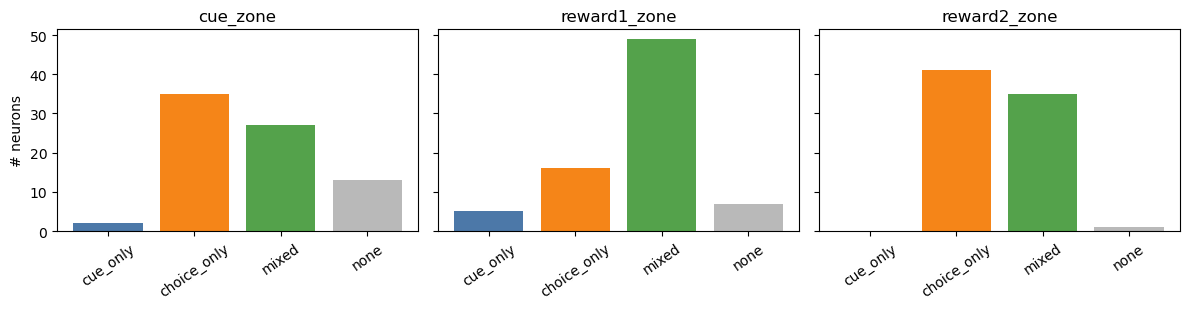

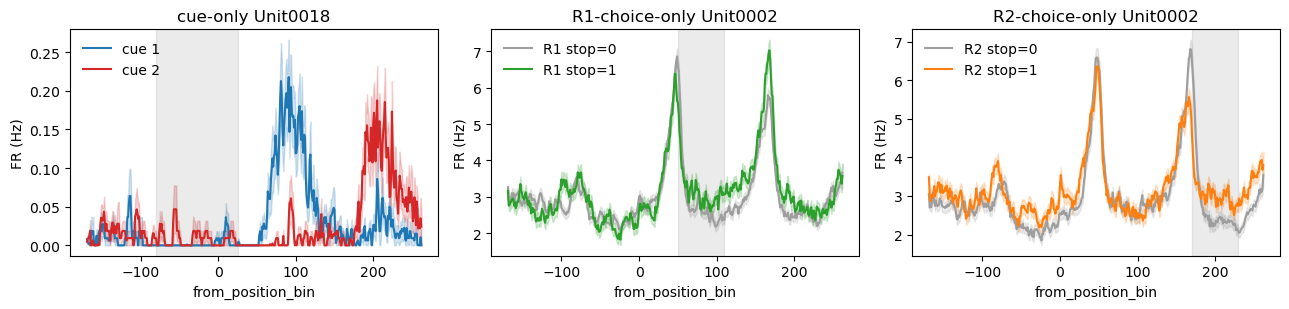

,phase,unit,effect,effect_size,p,q,sig
461,reward2_zone,Unit0077,choice,0.560211,0.000999,0.001202,True
371,reward2_zone,Unit0032,choice,0.782295,0.000999,0.001202,True
373,reward2_zone,Unit0033,choice,1.037351,0.000999,0.001202,True
375,reward2_zone,Unit0034,choice,2.215436,0.000999,0.001202,True
379,reward2_zone,Unit0036,choice,2.536119,0.000999,0.001202,True
381,reward2_zone,Unit0037,choice,0.707611,0.000999,0.001202,True
383,reward2_zone,Unit0038,choice,7.851874,0.000999,0.001202,True
385,reward2_zone,Unit0039,choice,0.425902,0.000999,0.001202,True
387,reward2_zone,Unit0040,choice,0.356694,0.000999,0.001202,True
391,reward2_zone,Unit0042,choice,1.857063,0.000999,0.001202,True


In [ ]:
# single-neuron selectivity (shuffle test)
unit_cols = [c for c in fr_track.columns if str(c).startswith('Unit')]
zones = {
    'cue_zone': (-80, 25),
    'reward1_zone': (50, 110),
    'reward2_zone': (170, 230),
}

x = fr_track.reset_index()[['session_id', 'trial_id', 'from_position_bin', 'cue', 'choice_R1', 'choice_R2', *unit_cols]].copy()
x = x[x['cue'].isin([1, 2])].copy()
x['choice_side'] = np.select([
    x['choice_R1'].fillna(False) & ~x['choice_R2'].fillna(False),
    x['choice_R2'].fillna(False) & ~x['choice_R1'].fillna(False),
], [1, 2], default=np.nan)

phase = {}
for name, (lo, hi) in zones.items():
    t = x[x['from_position_bin'].between(lo, hi, inclusive='left')]
    phase[name] = (t.groupby(['session_id', 'trial_id'], observed=True)
                    .agg({'cue': 'first', 'choice_side': 'first', 'choice_R1': 'first', 'choice_R2': 'first',
                          **{u: 'mean' for u in unit_cols}})
                    .reset_index())

def _w_abs_diff(y, lbl, strata):
    num = den = 0.0
    for s in np.unique(strata):
        m = strata == s
        g = lbl[m]
        if np.unique(g).size < 2:
            continue
        a, b = np.unique(g)[:2]
        num += m.sum() * np.abs(y[m][g == a].mean() - y[m][g == b].mean())
        den += m.sum()
    return np.nan if den == 0 else num / den

def _perm_p(y, eff, ctl, n_perm=1000, seed=0):
    rng = np.random.default_rng(seed)
    obs = _w_abs_diff(y, eff, ctl)
    if np.isnan(obs):
        return np.nan, np.nan
    null = np.empty(n_perm)
    for i in range(n_perm):
        p = eff.copy()
        for s in np.unique(ctl):
            idx = np.where(ctl == s)[0]
            p[idx] = rng.permutation(p[idx])
        null[i] = _w_abs_diff(y, p, ctl)
    return obs, (1 + (null >= obs).sum()) / (n_perm + 1)

def _fdr_bh(p):
    p = np.asarray(p, float)
    q = np.full_like(p, np.nan)
    ok = np.isfinite(p)
    if ok.sum() == 0:
        return q
    pv = p[ok]
    n = pv.size
    o = np.argsort(pv)
    r = pv[o]
    qv = np.empty(n)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        prev = min(prev, r[i] * n / (i + 1))
        qv[i] = prev
    z = np.empty(n)
    z[o] = qv
    q[ok] = z
    return q

rows = []
n_perm = 1000
for ph, dph in phase.items():
    cue = dph['cue'].to_numpy(int)
    if ph == 'cue_zone':
        keep = dph['choice_side'].notna().to_numpy()
        dph = dph.loc[keep].copy()
        cue = dph['cue'].to_numpy(int)
        choice = dph['choice_side'].to_numpy(int)
    elif ph == 'reward1_zone':
        choice = dph['choice_R1'].fillna(False).astype(int).to_numpy()
    else:
        choice = dph['choice_R2'].fillna(False).astype(int).to_numpy()

    for i, u in enumerate(unit_cols):
        y = dph[u].to_numpy(float)
        eff_cue, p_cue = _perm_p(y, cue, choice, n_perm=n_perm, seed=1000 + i)
        eff_ch, p_ch = _perm_p(y, choice, cue, n_perm=n_perm, seed=2000 + i)
        rows += [
            {'phase': ph, 'unit': u, 'effect': 'cue', 'effect_size': eff_cue, 'p': p_cue},
            {'phase': ph, 'unit': u, 'effect': 'choice', 'effect_size': eff_ch, 'p': p_ch},
        ]

sel = pd.DataFrame(rows)
sel['q'] = sel.groupby(['phase', 'effect'], observed=True)['p'].transform(_fdr_bh)
sel['sig'] = sel['q'] < 0.05

tab = sel.pivot_table(index=['phase', 'unit'], columns='effect', values='sig', aggfunc='first').fillna(False)
tab['class_label'] = np.select([
    tab['cue'] & ~tab['choice'],
    ~tab['cue'] & tab['choice'],
    tab['cue'] & tab['choice'],
], ['cue_only', 'choice_only', 'mixed'], default='none')

print('Significant neurons (q<0.05):')
print(sel.groupby(['phase', 'effect'])['sig'].sum())
print()
print('Class counts:')
print(tab.reset_index().groupby(['phase', 'class_label']).size())

fig, ax = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for j, ph in enumerate(['cue_zone', 'reward1_zone', 'reward2_zone']):
    c = tab.loc[ph, 'class_label'].value_counts().reindex(['cue_only', 'choice_only', 'mixed', 'none']).fillna(0)
    ax[j].bar(c.index, c.values, color=['#4C78A8', '#F58518', '#54A24B', '#B9B9B9'])
    ax[j].set_title(ph)
    ax[j].tick_params(axis='x', rotation=35)
ax[0].set_ylabel('# neurons')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
cue_only = tab.loc['cue_zone'][tab.loc['cue_zone', 'class_label'] == 'cue_only'].index.tolist() if 'cue_zone' in tab.index.get_level_values(0) else []
r1_only = tab.loc['reward1_zone'][tab.loc['reward1_zone', 'class_label'] == 'choice_only'].index.tolist() if 'reward1_zone' in tab.index.get_level_values(0) else []
r2_only = tab.loc['reward2_zone'][tab.loc['reward2_zone', 'class_label'] == 'choice_only'].index.tolist() if 'reward2_zone' in tab.index.get_level_values(0) else []

if cue_only:
    u = cue_only[0]
    for cval, col in [(1, '#1f77b4'), (2, '#d62728')]:
        g = x[x['cue'] == cval].groupby('from_position_bin')[u]
        m, s = g.mean(), g.sem(ddof=1).fillna(0)
        ax[0].plot(m.index, m.values, color=col, label=f'cue {cval}')
        ax[0].fill_between(m.index, (m - s).values, (m + s).values, color=col, alpha=.2)
    ax[0].axvspan(*zones['cue_zone'], color='k', alpha=.08)
    ax[0].set_title(f'cue-only {u}')
    ax[0].legend(frameon=False)

if r1_only:
    u = r1_only[0]
    for cval, col in [(0, '#9e9e9e'), (1, '#2ca02c')]:
        g = x[x['choice_R1'].fillna(False).astype(int) == cval].groupby('from_position_bin')[u]
        m, s = g.mean(), g.sem(ddof=1).fillna(0)
        ax[1].plot(m.index, m.values, color=col, label=f'R1 stop={cval}')
        ax[1].fill_between(m.index, (m - s).values, (m + s).values, color=col, alpha=.2)
    ax[1].axvspan(*zones['reward1_zone'], color='k', alpha=.08)
    ax[1].set_title(f'R1-choice-only {u}')
    ax[1].legend(frameon=False)

if r2_only:
    u = r2_only[0]
    for cval, col in [(0, '#9e9e9e'), (1, '#ff7f0e')]:
        g = x[x['choice_R2'].fillna(False).astype(int) == cval].groupby('from_position_bin')[u]
        m, s = g.mean(), g.sem(ddof=1).fillna(0)
        ax[2].plot(m.index, m.values, color=col, label=f'R2 stop={cval}')
        ax[2].fill_between(m.index, (m - s).values, (m + s).values, color=col, alpha=.2)
    ax[2].axvspan(*zones['reward2_zone'], color='k', alpha=.08)
    ax[2].set_title(f'R2-choice-only {u}')
    ax[2].legend(frameon=False)

for a in ax:
    a.set_xlabel('from_position_bin')
    a.set_ylabel('FR (Hz)')
plt.tight_layout()
plt.show()

# `sel` = long stats table; `tab` = per-neuron classes
sel.sort_values('q').head(20)



Combination counts:
cue_plus_correct_late_only    2
cue_only_no_late              0
stop_not_reward               0
dtype: int64

Cue-only and cue+correct-late unit IDs:
cue_only_no_late: []
cue_plus_correct_late_only: ['Unit0065', 'Unit0067']
stop_not_reward: []

Reward-zone choice-vs-reward summary:
         choice_not_reward  reward_not_choice  both  none
zone                                                     
reward1                 22                  6    39    10
reward2                 12                  4    58     3

Stop-not-reward neurons with cue specificity (q<0.05):
Series([], dtype: int64)


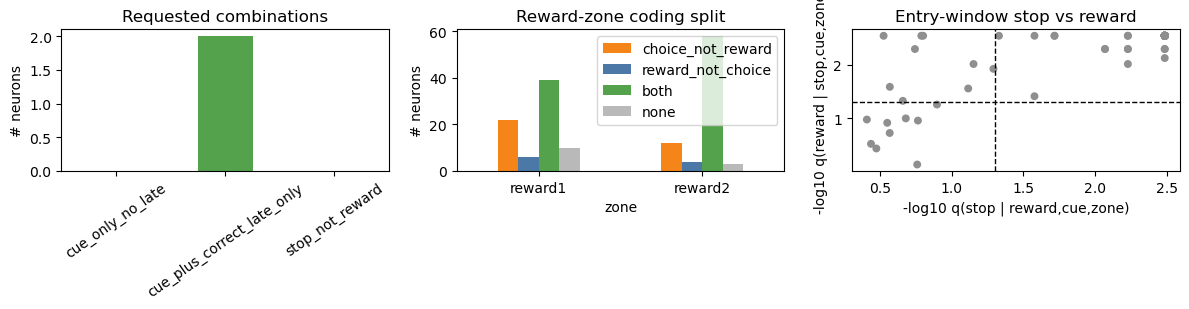

(          cue_only_no_late  cue_plus_correct_late_only  stop_not_reward
 Unit0001             False                       False            False
 Unit0002             False                       False            False
 Unit0003             False                       False            False
 Unit0004             False                       False            False
 Unit0005             False                       False            False
 ...                    ...                         ...              ...
 Unit0073             False                       False            False
 Unit0074             False                       False            False
 Unit0075             False                       False            False
 Unit0076             False                       False            False
 Unit0077             False                       False            False
 
 [77 rows x 3 columns],
          unit  choice_sig  choice_q  reward_sig  reward_q     zone  \
 0    Unit0001        True 

In [12]:
# Combination analyses: cue-only, cue+correct-later, and stop-vs-reward disentangling
unit_cols = [c for c in fr_track.columns if str(c).startswith('Unit')]

x2 = fr_track.reset_index()[[
    'session_id', 'trial_id', 'from_position_bin', 'cue', 'trial_outcome', 'choice_R1', 'choice_R2', *unit_cols
]].copy()
x2 = x2[x2['cue'].isin([1, 2])].copy()
x2['choice_side'] = np.select([
    x2['choice_R1'].fillna(False) & ~x2['choice_R2'].fillna(False),
    x2['choice_R2'].fillna(False) & ~x2['choice_R1'].fillna(False),
], [1, 2], default=np.nan)
x2['reward'] = (x2['trial_outcome'].fillna(0).astype(float) > 0).astype(int)

if '_perm_p' not in globals():
    def _w_abs_diff(y, lbl, strata):
        num = den = 0.0
        for s in np.unique(strata):
            m = strata == s
            g = lbl[m]
            if np.unique(g).size < 2:
                continue
            a, b = np.unique(g)[:2]
            num += m.sum() * np.abs(y[m][g == a].mean() - y[m][g == b].mean())
            den += m.sum()
        return np.nan if den == 0 else num / den
    def _perm_p(y, eff, ctl, n_perm=500, seed=0):
        rng = np.random.default_rng(seed)
        obs = _w_abs_diff(y, eff, ctl)
        if np.isnan(obs):
            return np.nan, np.nan
        null = np.empty(n_perm)
        for i in range(n_perm):
            p = eff.copy()
            for s in np.unique(ctl):
                idx = np.where(ctl == s)[0]
                p[idx] = rng.permutation(p[idx])
            null[i] = _w_abs_diff(y, p, ctl)
        return obs, (1 + (null >= obs).sum()) / (n_perm + 1)
    def _fdr_bh(p):
        p = np.asarray(p, float)
        q = np.full_like(p, np.nan)
        ok = np.isfinite(p)
        if ok.sum() == 0:
            return q
        pv = p[ok]
        n = pv.size
        o = np.argsort(pv)
        r = pv[o]
        qv = np.empty(n)
        prev = 1.0
        for i in range(n - 1, -1, -1):
            prev = min(prev, r[i] * n / (i + 1))
            qv[i] = prev
        z = np.empty(n)
        z[o] = qv
        q[ok] = z
        return q

def _w_signed_diff(y, lbl, strata):
    num = den = 0.0
    for s in np.unique(strata):
        m = strata == s
        g = lbl[m]
        vals = np.unique(g)
        if vals.size < 2:
            continue
        a, b = vals[0], vals[-1]
        num += m.sum() * (y[m][g == b].mean() - y[m][g == a].mean())
        den += m.sum()
    return np.nan if den == 0 else num / den

def zone_trial_avg(df, lo, hi):
    t = df[df['from_position_bin'].between(lo, hi, inclusive='left')]
    return (t.groupby(['session_id', 'trial_id'], observed=True)
             .agg({'cue': 'first', 'choice_side': 'first', 'choice_R1': 'first', 'choice_R2': 'first',
                   'reward': 'first', **{u: 'mean' for u in unit_cols}})
             .reset_index())

def run_effect_tests(df, eff_col, ctl_col, n_perm=500, seed0=0):
    e = df[eff_col].fillna(0).astype(int).to_numpy()
    c = df[ctl_col].fillna(0).astype(int).to_numpy()
    rows = []
    for i, u in enumerate(unit_cols):
        y = df[u].to_numpy(float)
        eff, p = _perm_p(y, e, c, n_perm=n_perm, seed=seed0 + i)
        sdiff = _w_signed_diff(y, e, c)
        rows.append({'unit': u, 'effect_size': eff, 'signed_diff': sdiff, 'p': p})
    out = pd.DataFrame(rows)
    out['q'] = _fdr_bh(out['p'].values)
    out['sig'] = out['q'] < 0.05
    return out

cue_df = zone_trial_avg(x2, -80, 25)
cue_df = cue_df[cue_df['choice_side'].notna()].copy()
r1_df = zone_trial_avg(x2, 50, 110)
r2_df = zone_trial_avg(x2, 170, 230)
r1_entry = zone_trial_avg(x2, 50, 70)
r2_entry = zone_trial_avg(x2, 170, 190)

# 1) Cue-only vs later-zone combinations using prior `tab`
za = (tab[['cue', 'choice']].reset_index()
      .assign(active=lambda d: d['cue'] | d['choice'])
      .pivot(index='unit', columns='phase', values='active')
      .reindex(unit_cols)
      .fillna(False))
for col in ['cue_zone', 'reward1_zone', 'reward2_zone']:
    if col not in za.columns:
        za[col] = False

combo = pd.DataFrame(index=unit_cols)
combo['cue_only_no_late'] = za['cue_zone'] & ~za['reward1_zone'] & ~za['reward2_zone']

# 2) "Cue + correct later zone only" using stop-choice effects matched to cue (control reward)
r1_match = run_effect_tests(r1_df[r1_df['cue'] == 1], 'choice_R1', 'reward', n_perm=500, seed0=10000)
r2_match = run_effect_tests(r2_df[r2_df['cue'] == 2], 'choice_R2', 'reward', n_perm=500, seed0=11000)
r1_unmatch = run_effect_tests(r1_df[r1_df['cue'] == 2], 'choice_R1', 'reward', n_perm=500, seed0=12000)
r2_unmatch = run_effect_tests(r2_df[r2_df['cue'] == 1], 'choice_R2', 'reward', n_perm=500, seed0=13000)

sig_match = (r1_match.set_index('unit')['sig'].reindex(unit_cols, fill_value=False)
             | r2_match.set_index('unit')['sig'].reindex(unit_cols, fill_value=False))
sig_unmatch = (r1_unmatch.set_index('unit')['sig'].reindex(unit_cols, fill_value=False)
               | r2_unmatch.set_index('unit')['sig'].reindex(unit_cols, fill_value=False))
combo['cue_plus_correct_late_only'] = za['cue_zone'] & sig_match & ~sig_unmatch

# 3) Beginning-of-reward-zone: stop vs reward disentangling
entry = pd.concat([
    r1_entry.assign(zone='R1', stop=r1_entry['choice_R1'].fillna(False).astype(int)),
    r2_entry.assign(zone='R2', stop=r2_entry['choice_R2'].fillna(False).astype(int)),
], ignore_index=True)
entry['zone_id'] = entry['zone'].map({'R1': 1, 'R2': 2}).astype(int)
entry['ctl_stop'] = (entry['reward'].astype(int) * 100 + entry['cue'].astype(int) * 10 + entry['zone_id']).astype(int)
entry['ctl_reward'] = (entry['stop'].astype(int) * 100 + entry['cue'].astype(int) * 10 + entry['zone_id']).astype(int)

stop_res = run_effect_tests(entry, 'stop', 'ctl_stop', n_perm=500, seed0=14000)
rew_res = run_effect_tests(entry, 'reward', 'ctl_reward', n_perm=500, seed0=15000)
entry_cmp = (stop_res[['unit', 'q', 'sig', 'signed_diff']].rename(columns={'q': 'q_stop', 'sig': 'sig_stop', 'signed_diff': 'dir_stop'})
             .merge(rew_res[['unit', 'q', 'sig', 'signed_diff']].rename(columns={'q': 'q_reward', 'sig': 'sig_reward', 'signed_diff': 'dir_reward'}), on='unit'))
entry_cmp['stop_not_reward'] = entry_cmp['sig_stop'] & (entry_cmp['dir_stop'] > 0) & ~entry_cmp['sig_reward']
combo = combo.join(entry_cmp.set_index('unit')['stop_not_reward'])
combo['stop_not_reward'] = combo['stop_not_reward'].fillna(False)

# 4) Reward-zone coding: reward-driven vs choice-driven (per zone)
r1_choice = run_effect_tests(r1_df, 'choice_R1', 'reward', n_perm=500, seed0=16000)
r1_reward = run_effect_tests(r1_df, 'reward', 'choice_R1', n_perm=500, seed0=17000)
r2_choice = run_effect_tests(r2_df, 'choice_R2', 'reward', n_perm=500, seed0=18000)
r2_reward = run_effect_tests(r2_df, 'reward', 'choice_R2', n_perm=500, seed0=19000)

def zone_cmp(choice_df, reward_df, zone_name):
    m = (choice_df[['unit', 'sig', 'q']].rename(columns={'sig': 'choice_sig', 'q': 'choice_q'})
         .merge(reward_df[['unit', 'sig', 'q']].rename(columns={'sig': 'reward_sig', 'q': 'reward_q'}), on='unit'))
    m['zone'] = zone_name
    m['choice_not_reward'] = m['choice_sig'] & ~m['reward_sig']
    m['reward_not_choice'] = m['reward_sig'] & ~m['choice_sig']
    m['both'] = m['choice_sig'] & m['reward_sig']
    m['none'] = ~m['choice_sig'] & ~m['reward_sig']
    return m

zr1 = zone_cmp(r1_choice, r1_reward, 'reward1')
zr2 = zone_cmp(r2_choice, r2_reward, 'reward2')
zone_mix = pd.concat([zr1, zr2], ignore_index=True)

# 5) Cue specificity and overlap with stop-not-reward neurons
cue_pref = run_effect_tests(cue_df, 'cue', 'choice_side', n_perm=500, seed0=20000)
cue_pref['cue_pref'] = np.where(cue_pref['signed_diff'] > 0, 'cue2>cue1', 'cue1>cue2')
stop_units = set(entry_cmp.loc[entry_cmp['stop_not_reward'], 'unit'])
cue_stop_overlap = cue_pref[cue_pref['unit'].isin(stop_units)].copy()

print('Combination counts:')
print(combo.sum().sort_values(ascending=False))
print()
print('Cue-only and cue+correct-late unit IDs:')
print('cue_only_no_late:', combo.index[combo['cue_only_no_late']].tolist())
print('cue_plus_correct_late_only:', combo.index[combo['cue_plus_correct_late_only']].tolist())
print('stop_not_reward:', combo.index[combo['stop_not_reward']].tolist())
print()
print('Reward-zone choice-vs-reward summary:')
print(zone_mix.groupby('zone')[['choice_not_reward', 'reward_not_choice', 'both', 'none']].sum())
print()
print('Stop-not-reward neurons with cue specificity (q<0.05):')
print(cue_stop_overlap[cue_stop_overlap['sig']].groupby('cue_pref').size())

fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
combo.sum().reindex(['cue_only_no_late', 'cue_plus_correct_late_only', 'stop_not_reward']).plot.bar(ax=ax[0], color=['#4C78A8', '#54A24B', '#F58518'])
ax[0].set_title('Requested combinations')
ax[0].tick_params(axis='x', rotation=35)
ax[0].set_ylabel('# neurons')

zone_counts = zone_mix.groupby('zone')[['choice_not_reward', 'reward_not_choice', 'both', 'none']].sum()
zone_counts.plot(kind='bar', ax=ax[1], color=['#F58518', '#4C78A8', '#54A24B', '#B9B9B9'])
ax[1].set_title('Reward-zone coding split')
ax[1].tick_params(axis='x', rotation=0)
ax[1].set_ylabel('# neurons')

ax[2].scatter(-np.log10(entry_cmp['q_stop'] + 1e-12), -np.log10(entry_cmp['q_reward'] + 1e-12), s=22, c=np.where(entry_cmp['stop_not_reward'], '#F58518', '#8f8f8f'))
ax[2].axvline(-np.log10(0.05), color='k', linestyle='--', linewidth=1)
ax[2].axhline(-np.log10(0.05), color='k', linestyle='--', linewidth=1)
ax[2].set_xlabel('-log10 q(stop | reward,cue,zone)')
ax[2].set_ylabel('-log10 q(reward | stop,cue,zone)')
ax[2].set_title('Entry-window stop vs reward')

plt.tight_layout()
plt.show()

combo, zone_mix, entry_cmp, cue_pref

